# DATASCI 530 - Assignment 2: Formula 1
<p style="text-align: center;">
By: Maxine Hakimi-Bulson
</p>


## Summary of Findings
Enter summary here!!! give breakdown of what f1 is and then the findings.

add some bullet points

### Loading Libraries and Data

In [2]:
# Import pandas, numpy, and matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Start by checking the codebook to figure out which table contains the relevant information.

# Read the datasets
circuits = pd.read_csv("data_raw/circuits.csv")
constructor_results = pd.read_csv("data_raw/constructor_results.csv")
constructor_standings = pd.read_csv("data_raw/constructor_standings.csv")
constructors = pd.read_csv("data_raw/constructors.csv")
driver_standings = pd.read_csv("data_raw/driver_standings.csv")
drivers = pd.read_csv("data_raw/drivers.csv")
lap_times = pd.read_csv("data_raw/lap_times.csv")
pit_stops = pd.read_csv("data_raw/pit_stops.csv")
qualifying = pd.read_csv("data_raw/qualifying.csv")
races = pd.read_csv("data_raw/races.csv")
results = pd.read_csv("data_raw/results.csv")
seasons = pd.read_csv("data_raw/seasons.csv")
status = pd.read_csv("data_raw/status.csv")

## Questions

### a) Which three constructors earned the most points between 1981 and 2020? How many total points did each of them earn? How do the total points for each constructor compare with the average across constructors?

In [5]:
sorted_constructor_standings = constructor_standings.sort_values(by=['constructorId', 'raceId'], ascending=[True, True])


In [6]:
# To answer this question, I need the points earned by each constructor, the year of each race, and the constructor name.
# The 'constructor_results' dataset contains the points earned by each constructor in each race,
# the 'races' dataset contains the year, and the 'constructors' dataset contains the constructor name.
# I will merge these datasets using 'raceId' and 'constructorId', then filter for 1981-2020.



# merge race then constructor_standings ('points' for whole season!!!) then constructors


# Merge constructor_results with races to get the year
constructor_merged = constructor_results.merge(
    races[['raceId', 'year']],
    on='raceId'
)

# Merge with constructors to get the constructor name
constructor_merged = constructor_merged.merge(
    constructors[['constructorId', 'name']],
    on='constructorId'
)

# Filter for years 1981 through 2020
constructor_merged_tf = constructor_merged[
    (constructor_merged['year'] >= 1981) &
    (constructor_merged['year'] <= 2020)
]


# Quality checks for the merged and filtered dataset

# Check the sample size
#print("Number of observations:", constructor_merged_tf.shape[0])
#print("Number of races:", constructor_merged_tf['raceId'].nunique())
#print("Number of constructors:", constructor_merged_tf['constructorId'].nunique())

# Check for missing values in the key variables
#print("\nMissing values in key variables:")
#print(
#    constructor_merged_tf[
#        ['raceId', 'constructorId', 'name', 'year', 'points']
#    ].isna().sum()
#)

# Examine descriptive statistics for constructor points per race
#print("\nDescriptive statistics for points per race:")
#print(constructor_merged_tf['points'].describe())


# Calculate the results

# Add up race points for each constructor
total_points_constructor = (
    constructor_merged_tf
    .groupby('name')['points']
    .sum()
    .reset_index()
)

# Find the three constructors with the most points
highest_points_constructor = (
    total_points_constructor
    .nlargest(3, 'points')
    .copy()
)

# Calculate average total points across all constructors
average_points_constructor = total_points_constructor['points'].mean()

# Add the average and comparison to the table
highest_points_constructor['average_points'] = average_points_constructor

highest_points_constructor['points_above_average'] = (
    highest_points_constructor['points']
    - highest_points_constructor['average_points']
)

# Give the columns clearer names
highest_points_constructor = highest_points_constructor.rename(
    columns={
        'name': 'Constructor',
        'points': 'Total Points',
        'average_points': 'Average Across Constructors',
        'points_above_average': 'Points Above Average'
    }
)

# Display as a formatted table
display(
    highest_points_constructor.style
    .hide(axis='index')
    .format({
        'Total Points': '{:,.1f}',
        'Average Across Constructors': '{:,.2f}',
        'Points Above Average': '{:,.2f}'
    })
    .set_caption('Top 3 Constructors from 1981–2020')
)

Constructor,Total Points,Average Across Constructors,Points Above Average
Ferrari,"7,374.0",532.24,"6,841.76"
Mercedes,"5,685.0",532.24,"5,152.76"
McLaren,"5,229.5",532.24,"4,697.26"


Ferrari, Mercedes, and McLaren earned the most points between 1981 and 2020. They earned a total of 7374, 5685, and 5229.5 points respectively. The top three constructors all earned well above the average points across constructors from 1981-2020, which was 532.24. Ferrari scored approximately 6800 more points than the average, Mercedes earned approximately 5150 points above the average, and McLaren scored approximately 4700 points above the average points across constructors from 1981-2020.

### b) Which three constructors earned the most points between 2001 and 2020? How many total points did each of them earn? How do the total points for each constructor compare with the average across constructors?

In [7]:
# Filter years between 2001 and 2020
constructor_merged_tf = constructor_merged[
    (constructor_merged['year'] >= 2001) &
    (constructor_merged['year'] <= 2020)
]

# Group by constructor name and sum the points
total_points_constructor = (
    constructor_merged_tf
    .groupby('name')['points']
    .sum()
    .reset_index()
)

# Find the average total points across all constructors
average_points_constructor = total_points_constructor['points'].mean()

# Get the three constructors with the most points
highest_points_constructor = (
    total_points_constructor
    .nlargest(3, 'points')
    .copy()
)

# Add the average and comparison columns
highest_points_constructor['average_points'] = average_points_constructor

highest_points_constructor['points_above_average'] = (
    highest_points_constructor['points']
    - highest_points_constructor['average_points']
)

# Rename columns for the final table
highest_points_constructor = highest_points_constructor.rename(
    columns={
        'name': 'Constructor',
        'points': 'Total Points',
        'average_points': 'Average Across Constructors',
        'points_above_average': 'Points Above Average'
    }
)

# Display the pretty table
display(
    highest_points_constructor.style
    .hide(axis='index')
    .format({
        'Total Points': '{:,.1f}',
        'Average Across Constructors': '{:,.2f}',
        'Points Above Average': '{:,.2f}'
    })
    .set_caption('Top 3 Constructors from 2001–2020')
)

Constructor,Total Points,Average Across Constructors,Points Above Average
Ferrari,"5,862.0",786.01,"5,075.99"
Mercedes,"5,685.0",786.01,"4,898.99"
Red Bull,"5,043.5",786.01,"4,257.49"


In [8]:

# Print the results
print("Top 3 Constructors from 2001-2020:")
print(highest_points_constructor)
print()
print(f"The average points across constructors from 2001-2020 is: {average_points_constructor:.2f}")

Top 3 Constructors from 2001-2020:
   Constructor  Total Points  Average Across Constructors  \
8      Ferrari        5862.0                   786.014286   
21    Mercedes        5685.0                   786.014286   
25    Red Bull        5043.5                   786.014286   

    Points Above Average  
8            5075.985714  
21           4898.985714  
25           4257.485714  

The average points across constructors from 2001-2020 is: 786.01


Ferrari, Mercedes, and Red Bull earned the most points between 2001 and 2020. They earned a total of 5862, 5685, and 5043.5 points respectively. The top three constructors all earned well above the average points across constructors from 2001-2020, which was 786.01. Ferrari and Mercedes scored approximately 5000 more points than the average, and Red Bull scored approximately 4200 points above the average points across constructors from 2001-2020.

### c) How did the rankings change across the two time periods?

Across the two time periods, the average points across constructors had increased by approximately 350 points from the 1981-2020 timeframe to the 2001-2020 timeframe, implying that the average points earned across constructors from 1981-2000 was much lower than the average points earned from 2001-2020. Additionally, it is noteworthy to mention how Ferrari and Mercedes have remained the first and second place constructors over time. Yet, the number of points earned by Mercedes in both timeframes is the same, meaning the Mercedes constructor had not started earning points until the 2001-2020 timeframe. Mercedes did not earn any points from 1981-2000. 

To continue, we notice that from 1981-2020, McLaren (5229.5 points) is the third place constructor based on points earned, yet Red Bull (5043.5 points) takes third place when looking at the timeframe from 2001-2020. This is interesting since McLaren has earned more points than Red Bull, but it was over a longer period of time. So, McLaren earned the majority of their points before 2001, explaining why Red Bull has taken third place as the top 3 constructor from 2001-2020.

### d) How many different drivers did Ferrari have between 1981 and 2020?

In [9]:
# to answer this, i need the driverId or driverRef or forename or surname to identify the different drivers, these variable are within the 'drivers' dataset.
# i also need to use 'year' variable which is in the 'races' dataset, and we need 'name' from 'constructors' dataset to filter for Ferrari.
# The results dataset contains raceId, driverId, and constructorId, so I can use it to connect the races and constructors datasets.

#results to races to constructors

# Merge results with races to add the year
f1 = results.merge(
    races[['raceId', 'year']],
    on='raceId'
)

# Merge with constructors to add the constructor name
f1 = f1.merge(
    constructors[['constructorId', 'name']],
    on='constructorId'
)

# Filter for Ferrari and years 1981 through 2020
ferrari = f1[
    (f1['name'] == 'Ferrari') &
    (f1['year'] >= 1981) &
    (f1['year'] <= 2020)
]

# Count the number of unique Ferrari drivers
ferrari['driverId'].nunique()

25

Between 1981 and 2020, Ferrari had 25 different drivers.

### e) What was the best year for Ferrari between 1981 and 2020?

In [10]:
# "best year" for ferrari could be based on points or wins. i need to check both, and see if the highest number of points earned and the highest number of wins 
# occur during the same year between 1981 and 2020

# i will be using the ferrari dataset we created in part d.

# Find Ferrari's total points for each year
ferrari_yearly_points = (
    ferrari
    .groupby('year')['points']
    .sum()
    .reset_index()
)

# Find the year with the most total points
best_year_points = ferrari_yearly_points.nlargest(1, 'points')

print(f"Ferrari's best year by points: {int(best_year_points['year'].iloc[0])} with {best_year_points['points'].iloc[0]} points")

# Find Ferrari's race wins
ferrari_wins = ferrari[ferrari['position'] == '1']

# Count wins in each year
ferrari_yearly_wins = (
    ferrari_wins
    .groupby('year')
    .size()
    .reset_index(name='wins')
)

# Find the year with the most wins
best_year_wins = ferrari_yearly_wins.nlargest(1, 'wins')

print(f"Ferrari's best year by wins: {int(best_year_wins['year'].iloc[0])} with {int(best_year_wins['wins'].iloc[0])} wins")

Ferrari's best year by points: 2018 with 571.0 points
Ferrari's best year by wins: 2002 with 15 wins


The best year for Ferrari between 1981 and 2020 in terms of points earned was the year 2018, having earned 571 points within that one year.

Ferrari's best year based on number of wins was 2002, having earned 15 wins that year.

## New Insight Questions

### (f) Compute an additional table or figure not included in the questions above.
#### Question: How many finishes has Ferrari had from 1981-2020? For the ones that did not finish, what were the most frequent reasons for not finishing?

Status,Count
Finished,856
+1 Lap,117
Engine,75
Collision,56
Spun off,33
Accident,33
Gearbox,28
Suspension,23
Turbo,20
Electrical,17


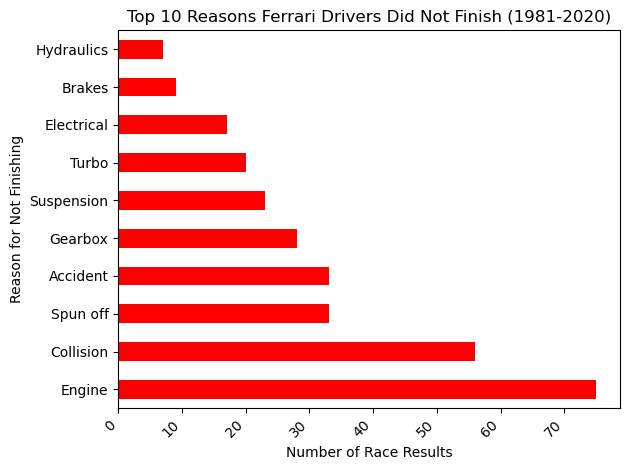

In [17]:
# Add finishing status information to the Ferrari dataframe from part (d)
ferrari_status = ferrari.merge(
    status[['statusId', 'status']],
    on='statusId'
)

# Count each Ferrari finishing status from 1981-2020
status_counts = ferrari_status['status'].value_counts().reset_index()

# Give the columns clearer names
status_counts.columns = ['Status', 'Count']

# Pretty table: Top 10 statuses overall
top_10_status = status_counts.head(10)

display(
    top_10_status.style
    .hide(axis='index')
    .set_caption('Top 10 Ferrari Driver Finishing Statuses (1981-2020)')
)

# Bar chart: Top 10 reasons for not finishing
# Remove statuses that represent finishing
not_finished = status_counts[
    (status_counts['Status'] != 'Finished') &
    (status_counts['Status'] != '+1 Lap') &
    (status_counts['Status'] != '+2 Laps')
]

# Plot the top 10 reasons for not finishing
not_finished.head(10).plot(
    kind='barh',
    x='Status',
    y='Count',
    legend=False,
    color = 'red'
)

plt.title('Top 10 Reasons Ferrari Drivers Did Not Finish (1981-2020)')
plt.ylabel('Reason for Not Finishing')
plt.xlabel('Number of Race Results')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### (g) What do we learn from this new table or figure?
From this histogram we learn that the top 10 reasons ferrari drivers from 1981-2020 did not finish the race was due to engine issues, collisions, the car spun off, there was an accident, or issues with their gearbox, suspension, turbo, electrical, brakes, or hydraulics.

In [3]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']